# Classification

In [1]:
import json

def load_jsonl(filename):
    data = {}
    with open(filename, 'r') as f:
        for line in f:
            if line.strip():
                obj = json.loads(line)
                data[obj['doi']] = obj
    return data

def get_metrics(y_true, y_pred, label):
    tp = sum(1 for t, p in zip(y_true, y_pred) if t == label and p == label)
    fp = sum(1 for t, p in zip(y_true, y_pred) if t != label and p == label)
    fn = sum(1 for t, p in zip(y_true, y_pred) if t == label and p != label)
    support = sum(1 for t in y_true if t == label)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return precision, recall, f1, support

# 1. Load Data
gt = load_jsonl('classification_human.jsonl')
pred = load_jsonl('classification_LLM.jsonl')
common_dois = [d for d in gt if d in pred]

# --- CATEGORY 1: Sol-Gel vs Non-Sol-Gel ---
y_true_c1 = ["sol gel" if gt[d]['classification'] == "sol gel synthesis" else "non sol gel" for d in common_dois]
y_pred_c1 = ["sol gel" if pred[d]['classification'] == "sol gel synthesis" else "non sol gel" for d in common_dois]

print(f"### Category 1: Synthesis Classification")
print(f"{'Label':<20} | {'Prec':<6} | {'Rec':<6} | {'F1':<6} | {'Support'}")
print("-" * 60)
for label in ["sol gel", "non sol gel"]:
    p, r, f1, s = get_metrics(y_true_c1, y_pred_c1, label)
    print(f"{label:<20} | {p:.3f} | {r:.3f} | {f1:.3f} | {s}")

# --- CATEGORY 2: Sol-Gel Inorganic vs Sol-Gel Mixed ---
# Uses strict logic: if GT is not sol-gel, it cannot be 'inorganic' or 'mixed'
def get_c2_label(item):
    if item.get('classification') == 'sol gel synthesis':
        if item.get('type') == 'inorganic': return "sol gel inorganic"
        if item.get('type') == 'mixed': return "sol gel mixed"
    return "noise"

y_true_c2 = [get_c2_label(gt[d]) for d in common_dois]
y_pred_c2 = [get_c2_label(pred[d]) for d in common_dois]

print(f"\n### Category 2: Material Type (Strict)")
print(f"{'Label':<20} | {'Prec':<6} | {'Rec':<6} | {'F1':<6} | {'Support'}")
print("-" * 60)
for label in ["sol gel inorganic", "sol gel mixed"]:
    p, r, f1, s = get_metrics(y_true_c2, y_pred_c2, label)
    print(f"{label:<20} | {p:.3f} | {r:.3f} | {f1:.3f} | {s}")

### Category 1: Synthesis Classification
Label                | Prec   | Rec    | F1     | Support
------------------------------------------------------------
sol gel              | 0.977 | 0.985 | 0.981 | 130
non sol gel          | 0.971 | 0.957 | 0.964 | 70

### Category 2: Material Type (Strict)
Label                | Prec   | Rec    | F1     | Support
------------------------------------------------------------
sol gel inorganic    | 0.981 | 0.911 | 0.944 | 112
sol gel mixed        | 0.667 | 1.000 | 0.800 | 18


                precision    recall  f1-score   support

       sol gel       0.98      0.98      0.98       130
   solid state       1.00      1.00      1.00         2
  hydrothermal       1.00      1.00      1.00        16
   precipitate       1.00      1.00      1.00        12
something else       0.95      0.93      0.94        40

      accuracy                           0.97       200
     macro avg       0.99      0.98      0.98       200
  weighted avg       0.97      0.97      0.97       200



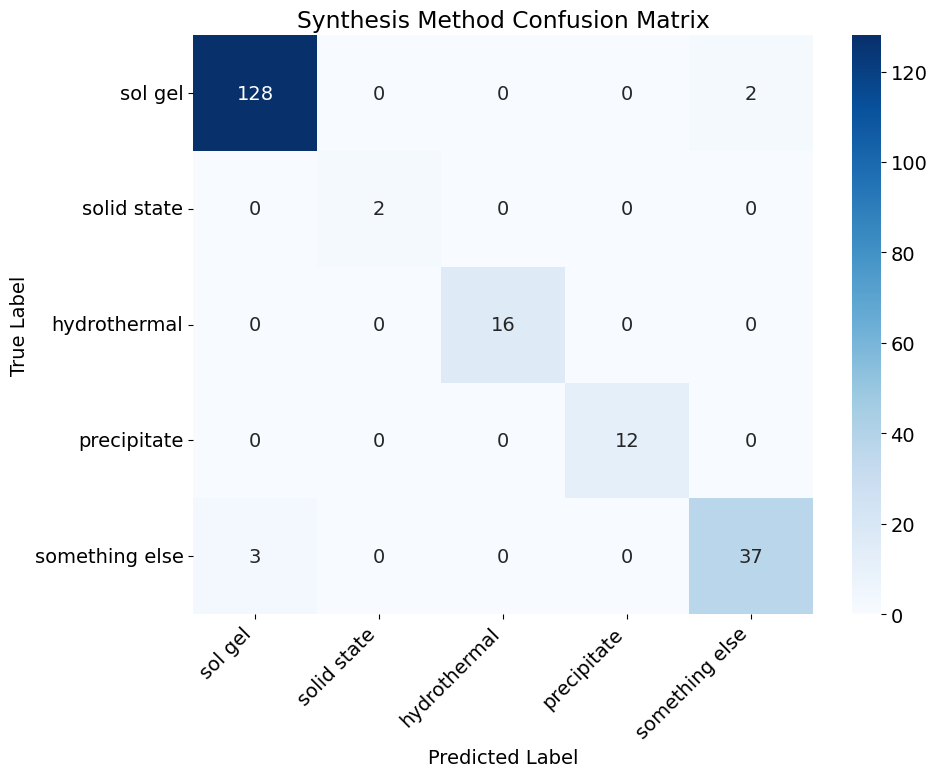

In [3]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

plt.rcParams.update({'font.size': 14})

def load_jsonl(filename):
    data = {}
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                obj = json.loads(line)
                data[obj['doi']] = obj
    return data

def map_label(label_str):
    """Maps raw JSON labels to your 5 target categories."""
    if not label_str:
        return "something else"
    
    label = label_str.lower()
    if "sol gel" in label:
        return "sol gel"
    elif "solid state" in label:
        return "solid state"
    elif "hydrothermal" in label:
        return "hydrothermal"
    elif "precipitate" in label or "precipitation" in label:
        return "precipitate"
    else:
        return "something else"

# 1. Load Data
gt = load_jsonl('classification_human.jsonl')
pred = load_jsonl('classification_LLM.jsonl')
common_dois = [d for d in gt if d in pred]

# 2. Extract and Map Labels
y_true = [map_label(gt[d].get('classification')) for d in common_dois]
y_pred = [map_label(pred[d].get('classification')) for d in common_dois]

# 3. Define Category Order for the Matrix
categories = ["sol gel", "solid state", "hydrothermal", "precipitate", "something else"]

# 4. Generate Plot
cm = confusion_matrix(y_true, y_pred, labels=categories)
df_cm = pd.DataFrame(cm, index=categories, columns=categories)

plt.figure(figsize=(10, 8))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Synthesis Method Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# 5. Print Report
print(classification_report(y_true, y_pred, labels=categories, target_names=categories))

# Extraction

In [4]:
import json
import pandas as pd
from collections import defaultdict

def load_jsonl(filepath, limit=286):
    """Loads JSONL data, handling empty lines and decoding errors."""
    data = []
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            for i, line in enumerate(f):
                if i >= limit: break
                stripped_line = line.strip()
                if not stripped_line:
                    data.append({})
                    continue
                try:
                    data.append(json.loads(stripped_line))
                except json.JSONDecodeError:
                    data.append(None)
    except FileNotFoundError:
        print(f"File {filepath} not found.")
        return None
    return data

def calculate_metrics(tp, fp, fn):
    """Standard Precision/Recall/F1 calculation."""
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return {
        'Precision': round(precision, 3),
        'Recall': round(recall, 3),
        'F1': round(f1, 3),
        'Support': tp + fn,
        'TP': tp, 'FP': fp, 'FN': fn
    }

def _is_empty(v):
    """Treats None AND "" (and whitespace) as absent. Required because the
    schema now represents missing values as "" rather than null."""
    return v is None or (isinstance(v, str) and v.strip() == "")

def compare_lists(gt_list, llm_list):
    """Compares lists as sets, ignoring nulls and empty strings."""
    gt_set = set(str(item).strip() for item in (gt_list or []) if item and item is not None)
    llm_set = set(str(item).strip() for item in (llm_list or []) if item and item is not None)
    if not gt_set and not llm_set: return 0, 0, 0
    tp = len(gt_set.intersection(llm_set))
    fp = len(llm_set - gt_set)
    fn = len(gt_set - llm_set)
    return tp, fp, fn

def compare_strings(gt_str, llm_str):
    """Exact string comparison."""
    gt_str = str(gt_str or "").strip()
    llm_str = str(llm_str or "").strip()
    if not gt_str and not llm_str: return 0, 0, 0
    if gt_str == llm_str: return 1, 0, 0
    return 0, (1 if llm_str else 0), (1 if gt_str else 0)

def compare_range_single(gt_dict, llm_dict, min_key='min_value', max_key='max_value'):
    """Treats a numeric range as ONE entity: BOTH min and max must match
    exactly to score a single TP. A partial/incorrect range is one FP and/or FN.
    Empty ('' or None) min AND max => the range is absent."""
    def vals(d):
        if not isinstance(d, dict): return (None, None)
        return d.get(min_key), d.get(max_key)
    g_min, g_max = vals(gt_dict)
    l_min, l_max = vals(llm_dict)
    gt_present = not (_is_empty(g_min) and _is_empty(g_max))
    llm_present = not (_is_empty(l_min) and _is_empty(l_max))
    if not gt_present and not llm_present: return 0, 0, 0
    if gt_present and llm_present and g_min == l_min and g_max == l_max:
        return 1, 0, 0
    return 0, (1 if llm_present else 0), (1 if gt_present else 0)

def extract_field(op, key, sub_key=None):
    """Pulls op[key], optionally drilling into a nested sub_key (e.g. the
    atmosphere dict {raw_string, atmosphere_normalized}). Falls back to the raw
    value if it isn't a dict, so old flat-string layouts still work."""
    val = op.get(key)
    if sub_key and isinstance(val, dict):
        return val.get(sub_key)
    return val

def safe_get_value(data_dict, path):
    """Traverses nested dictionary paths."""
    val = data_dict
    if not isinstance(val, dict): return None
    for key in path:
        if isinstance(val, dict): val = val.get(key)
        else: return None
    return val

# --- Configuration (new normalized schema; atmosphere is now a dict) ---
entities_to_evaluate = {
    'target_formula':       {'type': 'simple',       'path': ['protocol', 'target', 'material_formula']},
    'target_form':          {'type': 'simple',       'path': ['protocol', 'target', 'material_form']},
    'metal_precursors':     {'type': 'sub_key_list', 'path': ['protocol', 'metal_precursors'], 'key': 'material_formula'},
    'reagents_pubchem':     {'type': 'sub_key_list', 'path': ['protocol', 'reagents'], 'key': 'pubchem_CID'},
    # 'characterization':     {'type': 'list',         'path': ['phase_purity', 'characterization_methods', 'characterization_normalized']},
    'impurity_formula':     {'type': 'sub_key_list', 'path': ['phase_purity', 'impurity_phase'], 'key': 'material_formula'},
    'phase_classification': {'type': 'simple',       'path': ['phase_purity', 'classification']},
    'atmosphere':           {'type': 'op_list',      'path': ['operations'], 'key': 'atmosphere', 'sub_key': 'atmosphere_normalized', 'mode': 'exact'},
    'op_time':              {'type': 'op_list',      'path': ['operations'], 'key': 'time',        'mode': 'range', 'min_key': 'min_value', 'max_key': 'max_value'},
    'op_temp':              {'type': 'op_list',      'path': ['operations'], 'key': 'temperature', 'mode': 'range', 'min_key': 'min_value', 'max_key': 'max_value'},
    'op_pH':                {'type':'op_list',       'path': ['operations'], 'key': 'pH',          'mode': 'range', 'min_key': 'min_value', 'max_key': 'max_value'},
    'op_ratios':            {'type': 'op_list',      'path': ['operations'], 'key': 'ratios',      'mode': 'ratio_list'},
}

# --- Execution ---
GT_FILE = 'validation_human.jsonl'
LLM_FILE = 'validation_LLM.jsonl'
NUM_LINES = 286

gt_data = load_jsonl(GT_FILE, NUM_LINES)
llm_data = load_jsonl(LLM_FILE, NUM_LINES)
results = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})

if gt_data and llm_data:
    for i, (gt, llm) in enumerate(zip(gt_data, llm_data)):
        if llm is None: continue

        is_gt_empty = not gt or not any(gt.values())
        is_llm_empty = not llm or not any(llm.values())

        # --- Hallucination Penalty Logic (Field Specific) ---
        if is_gt_empty and not is_llm_empty:
            for entity, config in entities_to_evaluate.items():
                l_val = safe_get_value(llm, config['path'])
                if not l_val: continue
                count = 0
                if config['type'] == 'simple':
                    count = 1
                elif config['type'] in ['list', 'sub_key_list']:
                    count = len([x for x in (l_val or []) if x])
                elif config['type'] == 'op_list':
                    for op in (l_val or []):
                        if config.get('mode') == 'range':
                            field_data = op.get(config['key'])
                            if not isinstance(field_data, dict): continue
                            mn = field_data.get(config.get('min_key', 'min_value'))
                            mx = field_data.get(config.get('max_key', 'max_value'))
                            if not (_is_empty(mn) and _is_empty(mx)): count += 1   # range = 1 entity
                        elif config.get('mode') == 'ratio_list':
                            count += len(op.get(config['key']) or [])
                        else:  # exact (incl. atmosphere via sub_key)
                            if extract_field(op, config['key'], config.get('sub_key')): count += 1
                results[entity]['fp'] += count
                results[entity]['fn'] += count
            continue

        if gt is None: continue

        # --- Standard Comparison ---
        for entity, config in entities_to_evaluate.items():
            g_val = safe_get_value(gt, config['path'])
            l_val = safe_get_value(llm, config['path'])
            tp, fp, fn = 0, 0, 0

            if config['type'] == 'simple':
                tp, fp, fn = compare_strings(g_val, l_val)
            elif config['type'] == 'list':
                tp, fp, fn = compare_lists(g_val, l_val)
            elif config['type'] == 'sub_key_list':
                g_list_raw = [item.get(config['key']) for item in (g_val or [])]
                l_list_raw = [item.get(config['key']) for item in (l_val or [])]
                g_set = set(str(x).strip() for x in g_list_raw if x)
                l_set = set(str(x).strip() for x in l_list_raw if x)
                tp = len(g_set.intersection(l_set))

                gt_count, llm_count = len(g_val or []), len(l_val or [])
                if llm_count > gt_count:
                    fp = max(len(l_set - g_set), llm_count - gt_count)
                else:
                    fp = len(l_set - g_set)

                if gt_count > llm_count:
                    fn = gt_count - llm_count
                else:
                    fn = len(g_set - l_set)

            elif config['type'] == 'op_list':
                ops_gt, ops_llm = (g_val or []), (l_val or [])
                mk, xk = config.get('min_key', 'min_value'), config.get('max_key', 'max_value')
                sk = config.get('sub_key')
                for idx in range(max(len(ops_gt), len(ops_llm))):
                    op_g = ops_gt[idx] if idx < len(ops_gt) else {}
                    op_l = ops_llm[idx] if idx < len(ops_llm) else {}
                    if config['mode'] == 'range':
                        t, f, n = compare_range_single(op_g.get(config['key']), op_l.get(config['key']), mk, xk)
                    elif config['mode'] == 'ratio_list':
                        o_g, o_l = op_g.get(config['key']), op_l.get(config['key'])
                        gr = [f"{r.get('type')}|{r.get('value')}|{r.get('description')}" for r in (o_g or []) if isinstance(r, dict)]
                        lr = [f"{r.get('type')}|{r.get('value')}|{r.get('description')}" for r in (o_l or []) if isinstance(r, dict)]
                        t, f, n = compare_lists(gr, lr)
                    else:  # exact (atmosphere reads the nested atmosphere_normalized)
                        t, f, n = compare_strings(extract_field(op_g, config['key'], sk),
                                                  extract_field(op_l, config['key'], sk))
                    tp += t; fp += f; fn += n

            results[entity]['tp'] += tp
            results[entity]['fp'] += fp
            results[entity]['fn'] += fn

# --- Presentation ---
metrics_list = {k: calculate_metrics(v['tp'], v['fp'], v['fn']) for k, v in results.items()}
print("\nValidation Results:")
print(pd.DataFrame.from_dict(metrics_list, orient='index')[['Precision', 'Recall', 'F1', 'Support', 'TP', 'FP', 'FN']])


Validation Results:
                      Precision  Recall     F1  Support   TP  FP  FN
target_formula            0.965   0.953  0.959      257  245   9  12
target_form               0.948   0.948  0.948      286  271  15  15
metal_precursors          0.950   0.936  0.943      624  584  31  40
reagents_pubchem          0.927   0.956  0.941      732  700  55  32
impurity_formula          0.977   0.896  0.935       48   43   1   5
phase_classification      0.899   0.899  0.899      286  257  29  29
atmosphere                0.950   0.947  0.948      243  230  12  13
op_time                   0.969   0.969  0.969      752  729  23  23
op_temp                   0.969   0.968  0.968      774  749  24  25
op_pH                     0.980   0.980  0.980       50   49   1   1
op_ratios                 0.955   0.969  0.962      262  254  12   8


                   precision    recall  f1-score   support

             Pure       0.91      0.99      0.95       202
           Impure       0.96      0.94      0.95        50
Insufficient info       1.00      0.37      0.54        27

         accuracy                           0.92       279
        macro avg       0.96      0.77      0.81       279
     weighted avg       0.93      0.92      0.91       279



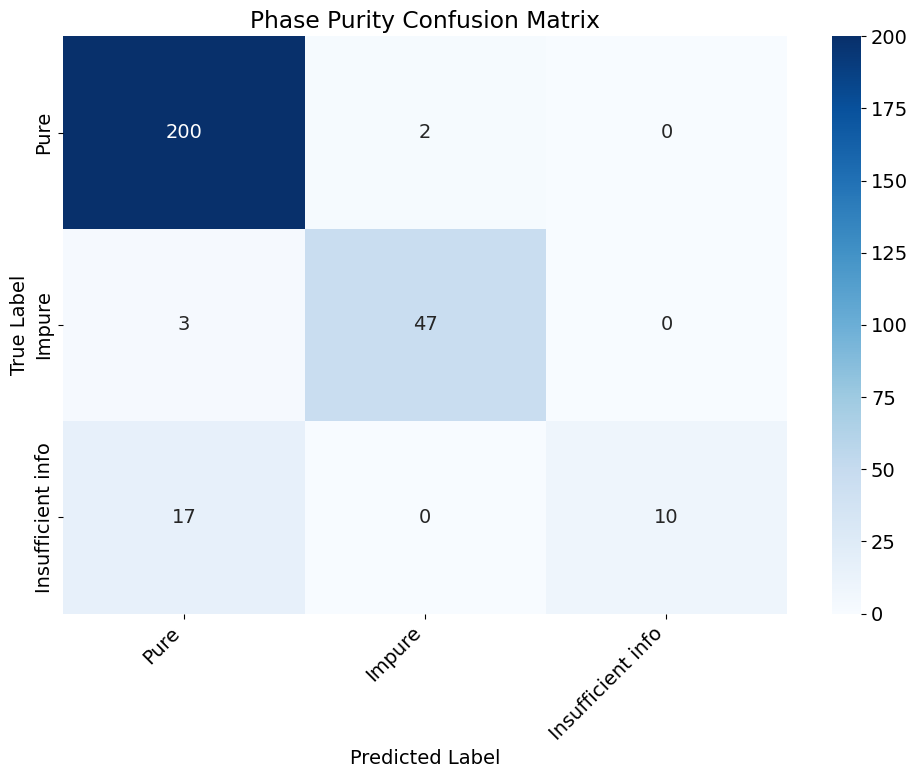

In [6]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

plt.rcParams.update({'font.size': 14})

def load_jsonl(filename, limit=286):
    """Line-aligned load: the GT and raw files are matched by index, not DOI."""
    data = []
    with open(filename, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= limit: break
            data.append(json.loads(line) if line.strip() else {})
    return data

def get_class(record):
    return ((record or {}).get('phase_purity') or {}).get('classification')

# 1. Load Data
gt = load_jsonl('validation_human.jsonl')
pred = load_jsonl('validation_LLM.jsonl')

# 2. Extract Labels (skip records with no ground-truth label)
y_true, y_pred = [], []
for g, p in zip(gt, pred):
    t = get_class(g)
    if t:
        y_true.append(t)
        y_pred.append(get_class(p) or "none")

# 3. Define Category Order for the Matrix
categories = ["Pure", "Impure", "Insufficient info"]

# 4. Generate Plot
cm = confusion_matrix(y_true, y_pred, labels=categories)
df_cm = pd.DataFrame(cm, index=categories, columns=categories)

plt.figure(figsize=(10, 8))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Phase Purity Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# 5. Print Report
print(classification_report(y_true, y_pred, labels=categories, target_names=categories))




# Record Level Accuracy

In [7]:
# =====================================================================
# RECORD-LEVEL ACCURACY  (perfect records / total records)
# Denominator = all 286 validation records.
# A record is PERFECT iff it produces zero FP and zero FN across every
# evaluated field, i.e. the whole record is TP-only.
# Run AFTER the extraction-metrics cell: reuses load_jsonl, safe_get_value,
# compare_*, extract_field, _is_empty and entities_to_evaluate so that
# "correct" means exactly what it means in the field-level table.
# =====================================================================
import pandas as pd
from collections import defaultdict

GT_FILE   = 'validation_human.jsonl'
LLM_FILE  = 'validation_LLM.jsonl'
NUM_LINES = 286

gt_data  = load_jsonl(GT_FILE,  NUM_LINES)
llm_data = load_jsonl(LLM_FILE, NUM_LINES)


def _count_entities(llm, config):
    """Number of entities a field holds in the prediction. Used to penalise
    records whose ground truth is empty (nothing should have been extracted)."""
    l_val = safe_get_value(llm, config['path'])
    if not l_val:
        return 0
    if config['type'] == 'simple':
        return 1
    if config['type'] in ('list', 'sub_key_list'):
        return len([x for x in (l_val or []) if x])
    if config['type'] == 'op_list':
        count = 0
        for op in (l_val or []):
            if config.get('mode') == 'range':
                fd = op.get(config['key'])
                if not isinstance(fd, dict):
                    continue
                mn = fd.get(config.get('min_key', 'min_value'))
                mx = fd.get(config.get('max_key', 'max_value'))
                if not (_is_empty(mn) and _is_empty(mx)):
                    count += 1
            elif config.get('mode') == 'ratio_list':
                count += len(op.get(config['key']) or [])
            else:
                if extract_field(op, config['key'], config.get('sub_key')):
                    count += 1
        return count
    return 0


def score_record(gt, llm):
    """{field: (tp, fp, fn)} for one record, using the same comparison rules
    as the aggregate field-level table."""
    per_field = {}
    is_gt_empty  = (not gt)  or (not any(gt.values()))
    is_llm_empty = (not llm) or (not any(llm.values()))

    # Ground truth holds no recipe but the model emitted one: every entity it
    # invented counts as both an FP and an FN (same rule as the cell above).
    if is_gt_empty and not is_llm_empty:
        for entity, config in entities_to_evaluate.items():
            c = _count_entities(llm, config)
            per_field[entity] = (0, c, c)
        return per_field

    for entity, config in entities_to_evaluate.items():
        g_val = safe_get_value(gt,  config['path'])
        l_val = safe_get_value(llm, config['path'])
        tp = fp = fn = 0

        if config['type'] == 'simple':
            tp, fp, fn = compare_strings(g_val, l_val)

        elif config['type'] == 'list':
            tp, fp, fn = compare_lists(g_val, l_val)

        elif config['type'] == 'sub_key_list':
            g_set = set(str(item.get(config['key'])).strip()
                        for item in (g_val or []) if item.get(config['key']))
            l_set = set(str(item.get(config['key'])).strip()
                        for item in (l_val or []) if item.get(config['key']))
            tp = len(g_set & l_set)
            gt_count, llm_count = len(g_val or []), len(l_val or [])
            fp = max(len(l_set - g_set), llm_count - gt_count) if llm_count > gt_count else len(l_set - g_set)
            fn = (gt_count - llm_count) if gt_count > llm_count else len(g_set - l_set)

        elif config['type'] == 'op_list':
            ops_gt, ops_llm = (g_val or []), (l_val or [])
            mk = config.get('min_key', 'min_value')
            xk = config.get('max_key', 'max_value')
            sk = config.get('sub_key')
            for idx in range(max(len(ops_gt), len(ops_llm))):
                op_g = ops_gt[idx]  if idx < len(ops_gt)  else {}
                op_l = ops_llm[idx] if idx < len(ops_llm) else {}
                if config['mode'] == 'range':
                    t, f, n = compare_range_single(op_g.get(config['key']),
                                                  op_l.get(config['key']), mk, xk)
                elif config['mode'] == 'ratio_list':
                    gr = [f"{r.get('type')}|{r.get('value')}|{r.get('description')}"
                          for r in (op_g.get(config['key']) or []) if isinstance(r, dict)]
                    lr = [f"{r.get('type')}|{r.get('value')}|{r.get('description')}"
                          for r in (op_l.get(config['key']) or []) if isinstance(r, dict)]
                    t, f, n = compare_lists(gr, lr)
                else:
                    t, f, n = compare_strings(extract_field(op_g, config['key'], sk),
                                              extract_field(op_l, config['key'], sk))
                tp += t; fp += f; fn += n

        per_field[entity] = (tp, fp, fn)
    return per_field


# --- score all 286 records ---
rows = []
for i, (gt, llm) in enumerate(zip(gt_data, llm_data)):
    if gt is None or llm is None:          # unparseable line = not a perfect record
        rows.append({'idx': i, 'perfect': False, 'tp': 0, 'fp': 0, 'fn': 0,
                     'bad_fields': ['<unparseable>']})
        continue
    pf = score_record(gt, llm)
    tp = sum(v[0] for v in pf.values())
    fp = sum(v[1] for v in pf.values())
    fn = sum(v[2] for v in pf.values())
    rows.append({'idx': i, 'perfect': (fp == 0 and fn == 0),
                 'tp': tp, 'fp': fp, 'fn': fn,
                 'bad_fields': [k for k, v in pf.items() if v[1] or v[2]]})

rec = pd.DataFrame(rows)

total     = len(rec)
n_perfect = int(rec['perfect'].sum())

print("=" * 66)
print("RECORD-LEVEL ACCURACY  (perfect records / total records)")
print(f"A record is perfect only if it produces zero FP and zero FN across")
print(f"all {len(entities_to_evaluate)} evaluated fields.")
print("=" * 66)
print(f"  total records ........... {total}")
print(f"  perfect records ......... {n_perfect}")
print(f"  imperfect records ....... {total - n_perfect}")
print(f"  record-level accuracy ... {n_perfect / total:.3f}  ({100 * n_perfect / total:.1f}%)")

# --- which fields break the imperfect records ---
fail_counts = defaultdict(int)
for bf in rec.loc[~rec['perfect'], 'bad_fields']:
    for f in bf:
        fail_counts[f] += 1
n_imperfect = total - n_perfect

print(f"\nFields responsible for the {n_imperfect} imperfect records "
      f"(a record can fail on more than one):")
fail_df = (pd.DataFrame({'records_failed': fail_counts})
             .sort_values('records_failed', ascending=False))
fail_df['share_of_imperfect'] = (fail_df['records_failed'] / n_imperfect).round(3)
print(fail_df)

print("\nErrors per record (FP+FN) — shows how many imperfect records are near-misses:")
print((rec['fp'] + rec['fn']).value_counts().sort_index())



RECORD-LEVEL ACCURACY  (perfect records / total records)
A record is perfect only if it produces zero FP and zero FN across
all 11 evaluated fields.
  total records ........... 286
  perfect records ......... 197
  imperfect records ....... 89
  record-level accuracy ... 0.689  (68.9%)

Fields responsible for the 89 imperfect records (a record can fail on more than one):
                      records_failed  share_of_imperfect
metal_precursors                  43               0.483
phase_classification              29               0.326
reagents_pubchem                  26               0.292
op_temp                           17               0.191
target_form                       15               0.169
op_time                           14               0.157
target_formula                    12               0.135
op_ratios                         12               0.135
atmosphere                         9               0.101
impurity_formula                   6               0.067

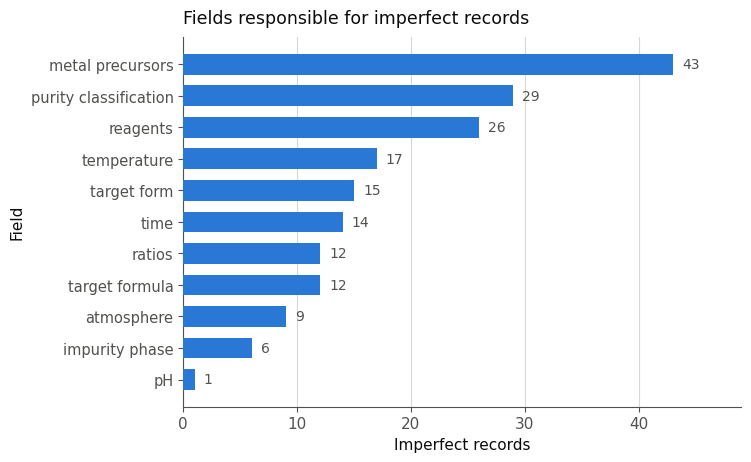

In [8]:
# --- shared style (run once) ---------------------------------------------
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

BLUE, GRAY = '#2a78d6', '#bdbcb6'
INK, INK2, GRID = '#0b0b0b', '#52514e', '#d8d7d1'

mpl.rcParams.update({
    'font.size': 11, 'axes.edgecolor': INK2, 'axes.labelcolor': INK,
    'text.color': INK, 'xtick.color': INK2, 'ytick.color': INK2,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

PRETTY = {
    'target_formula': 'target formula', 'target_form': 'target form',
    'metal_precursors': 'metal precursors', 'reagents_pubchem': 'reagents',
    'impurity_formula': 'impurity phase', 'phase_classification': 'purity classification',
    'atmosphere': 'atmosphere', 'op_time': 'time', 'op_temp': 'temperature',
    'op_pH': 'pH', 'op_ratios': 'ratios', '<unparseable>': 'unparseable',
}

# --- FIGURE 1: fields responsible for imperfect records -------------------
fig1, ax = plt.subplots(figsize=(7.2, 4.8))
fa = fail_df.sort_values('records_failed')
y = np.arange(len(fa))
ax.barh(y, fa['records_failed'].values, height=0.66, color=BLUE, zorder=3)
ax.set_yticks(y)
ax.set_yticklabels([PRETTY.get(f, f) for f in fa.index], fontsize=10.5)
for yi, v in zip(y, fa['records_failed'].values):
    ax.text(v + 0.8, yi, str(v), va='center', fontsize=10, color=INK2)
ax.set_xlim(0, fa['records_failed'].max() * 1.14)
ax.set_xlabel('Imperfect records')
ax.set_ylabel('Field')
ax.xaxis.grid(True, color=GRID, lw=0.8)
ax.set_axisbelow(True)
ax.set_title('Fields responsible for imperfect records', fontsize=12.5,
             loc='left', pad=10)
plt.show()

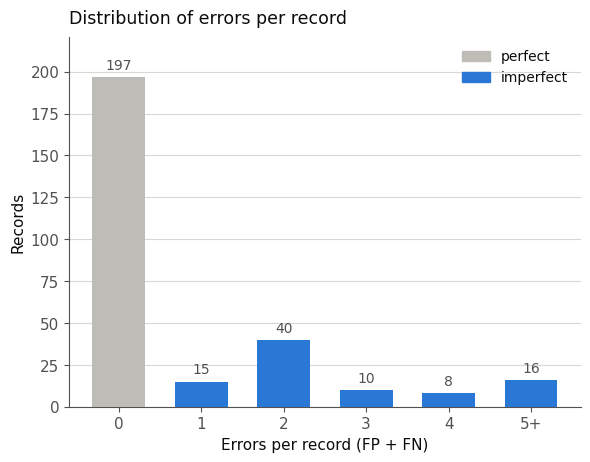

In [9]:
# --- FIGURE 2: errors per record ------------------------------------------
fig2, ax = plt.subplots(figsize=(6.6, 4.8))
err = rec['fp'] + rec['fn']
bins = ['0', '1', '2', '3', '4', '5+']
counts = [int((err == k).sum()) for k in range(5)] + [int((err >= 5).sum())]
x = np.arange(len(bins))
ax.bar(x, counts, width=0.64, color=[GRAY] + [BLUE] * 5, zorder=3)
for xi, c in zip(x, counts):
    ax.text(xi, c + max(counts) * 0.015, str(c), ha='center', va='bottom',
            fontsize=10, color=INK2)
ax.set_xticks(x)
ax.set_xticklabels(bins, fontsize=11)
ax.set_ylim(0, max(counts) * 1.12)
ax.set_xlabel('Errors per record (FP + FN)')
ax.set_ylabel('Records')
ax.yaxis.grid(True, color=GRID, lw=0.8)
ax.set_axisbelow(True)
ax.set_title('Distribution of errors per record', fontsize=12.5, loc='left', pad=10)
ax.legend([plt.Rectangle((0, 0), 1, 1, color=GRAY),
           plt.Rectangle((0, 0), 1, 1, color=BLUE)],
          ['perfect', 'imperfect'], frameon=False, fontsize=10,
          loc='upper right')
plt.show()


In [10]:
# =====================================================================
# RECORD-LEVEL ACCURACY BY FIELD CATEGORY
# A record is correct for a category if EVERY field in that category has
# zero FP and zero FN. Denominator = all 286 validation records.
# Run AFTER the record-level cell: reuses score_record, gt_data, llm_data.
# =====================================================================
import numpy as np
import pandas as pd

FIELDS = list(entities_to_evaluate.keys())

# per-record, per-field: clean (no FP, no FN) or not
clean_rows = []
for gt, llm in zip(gt_data, llm_data):
    if gt is None or llm is None:
        clean_rows.append([False] * len(FIELDS))
        continue
    pf = score_record(gt, llm)
    clean_rows.append([(pf[f][1] == 0 and pf[f][2] == 0) for f in FIELDS])
CLEAN = np.array(clean_rows, dtype=bool)
N_REC = CLEAN.shape[0]

# --- building blocks -----------------------------------------------------
TARGET     = ['target_formula']       
PRECURSOR  = ['metal_precursors']
REAGENTS   = ['reagents_pubchem']
OUTCOME    = ['phase_classification', 'impurity_formula']
CONDITIONS = ['op_temp', 'op_time', 'op_pH', 'atmosphere']

CATEGORIES = [
    ('Target',
     'Target only',
     TARGET),
    ('Target-Precursor',
     'Target and precursor',
     TARGET + PRECURSOR),
    ('Target-Outcome',
     'Target and synthesis outcomes (phase classification, and impurity phase)',
     TARGET + OUTCOME),
    ('Synthesis conditions',
     'Temperature, time, pH, and atmosphere',
     CONDITIONS),
    ('Target-Precursor-Reagents-Outcome',
     'Target, precursor, reagents, and synthesis outcomes',
     TARGET + PRECURSOR + REAGENTS + OUTCOME),
    ('Target-Precursor-Conditions-Outcome',
     'Target, precursor, synthesis conditions, and synthesis outcomes',
     TARGET + PRECURSOR + CONDITIONS + OUTCOME),
    ('Overall',
     'All 11 fields',
     FIELDS),
]

rows = []
for category, description, fields in CATEGORIES:
    fields = list(dict.fromkeys(fields))                    # de-dup, keep order
    n_correct = int(CLEAN[:, [FIELDS.index(f) for f in fields]].all(axis=1).sum())
    rows.append({
        'Category': category,
        'Description': description,
        '# of Fields': len(fields),
        'Correct / Total': f'{n_correct} / {N_REC}',
        'Accuracy': round(n_correct / N_REC, 3),
    })

table = pd.DataFrame(rows)
print(table.to_string(index=False))



                           Category                                                              Description  # of Fields Correct / Total  Accuracy
                             Target                                                              Target only            1       274 / 286     0.958
                   Target-Precursor                                                     Target and precursor            2       235 / 286     0.822
                     Target-Outcome Target and synthesis outcomes (phase classification, and impurity phase)            3       249 / 286     0.871
               Synthesis conditions                                    Temperature, time, pH, and atmosphere            4       262 / 286     0.916
  Target-Precursor-Reagents-Outcome                      Target, precursor, reagents, and synthesis outcomes            5       215 / 286     0.752
Target-Precursor-Conditions-Outcome          Target, precursor, synthesis conditions, and synthesis outcomes    

# Paper Level Metrics

In [ ]:
import json
import pandas as pd
from collections import defaultdict

CATEGORY_FILE = 'paper_level_categories.jsonl'
CATEGORIES = ['correct', 'field errors', 'merged', 'split', 'misclassified']

papers = pd.DataFrame([json.loads(l) for l in open(CATEGORY_FILE) if l.strip()])

counts = defaultdict(int)
for r in llm_data:
    d = ((r or {}).get('protocol') or {}).get('doi')
    if d:
        counts[d] += 1
papers['n_llm'] = papers['doi'].map(counts).fillna(0).astype(int)

papers['has_merged']     = papers['category'] == 'merged'
papers['split']          = papers['category'] == 'split'
papers['misclassified']  = papers['category'] == 'misclassified'
papers['correct_strict'] = papers['category'] == 'correct'

N = len(papers)
n_strict = int(papers['correct_strict'].sum())

brk = (papers['category'].value_counts()
       .reindex(CATEGORIES).fillna(0).astype(int)
       .rename_axis('category').reset_index(name='papers'))
brk['share'] = (brk['papers'] / N).round(3)

print("=" * 72)
print(f"PAPER-LEVEL BREAKDOWN  ({N} papers)")
print("=" * 72)
print(brk.to_string(index=False))
print(f"\npaper-level accuracy .................... {n_strict}/{N} = {n_strict/N:.3f}")


PAPER-LEVEL BREAKDOWN  (104 papers)
     category  papers  share
      correct      51  0.490
 field errors      34  0.327
       merged      15  0.144
        split       2  0.019
misclassified       2  0.019

paper-level accuracy .................... 51/104 = 0.490


In [13]:
# =====================================================================
# MASTER TABLE -- field / record / paper
#
# Each level ANDs the level below over a wider scope, so accuracy can only
# fall as you descend the table. "Ceiling" is the highest value the level
# could take GIVEN the level below it, i.e. if every error were packed into
# as few units as possible.
#
# Run AFTER the record-level cell and the paper-level cell:
# reuses score_record, gt_data, llm_data, entities_to_evaluate, papers.
# =====================================================================
import numpy as np
import pandas as pd

FIELDS = list(entities_to_evaluate.keys())

# ---- field x record cleanliness matrix ----------------------------------
CLEAN = np.array([[ (pf[f][1] == 0 and pf[f][2] == 0) for f in FIELDS ]
                  for pf in (score_record(a, b) for a, b in zip(gt_data, llm_data))],
                 dtype=bool)
N_REC, N_F = CLEAN.shape
per_field = dict(zip(FIELDS, CLEAN.mean(axis=0)))

n_cells       = CLEAN.size
n_cells_clean = int(CLEAN.sum())
n_rec_perfect = int(CLEAN.all(axis=1).sum())

N_PAP        = len(papers)
n_pap_strict = int(papers['correct_strict'].sum())

# ---- ceilings -----------------------------------------------------------
# record given field: a record needs EVERY field clean, so it cannot beat
# the weakest field's clean rate.
ceil_record = min(per_field.values())

# paper given record + structure: papers that fail structurally are doomed
# regardless of field content, so pack the imperfect records into them first;
# any left over must break further papers, largest ones first.
sizes = papers.set_index('doi')['n_llm'].sort_values(ascending=False)
n_bad_records = N_REC - n_rec_perfect
doomed = papers[papers['has_merged'] | papers['misclassified'] | papers['split']]
n_doomed = len(doomed)
extra = max(0, n_bad_records - int(doomed['n_llm'].sum()))
extra_papers = 0
for s in sizes[~sizes.index.isin(doomed['doi'])]:
    if extra <= 0:
        break
    extra -= s
    extra_papers += 1
ceil_paper = (N_PAP - n_doomed - extra_papers) / N_PAP

# ---- assemble -----------------------------------------------------------
master = pd.DataFrame([
    {'Level': 'Field',
     'Criterion': 'one field of one record exactly right (no FP, no FN)',
     'Unit': 'field-record', 'N': n_cells,
     'Correct': n_cells_clean, 'Accuracy': n_cells_clean / n_cells,
     'Ceiling': 1.000},
    {'Level': 'Record',
     'Criterion': f'all {N_F} fields of the record right',
     'Unit': 'record', 'N': N_REC,
     'Correct': n_rec_perfect, 'Accuracy': n_rec_perfect / N_REC,
     'Ceiling': ceil_record},
    {'Level': 'Paper',
     'Criterion': ('every record right, variant count matches, '
                   'and every record resolves to one experiment'),
     'Unit': 'paper', 'N': N_PAP,
     'Correct': n_pap_strict, 'Accuracy': n_pap_strict / N_PAP,
     'Ceiling': ceil_paper},
])
master['Accuracy']    = master['Accuracy'].round(3)
master['Ceiling']     = master['Ceiling'].round(3)
master['Correct / N'] = master['Correct'].astype(str) + ' / ' + master['N'].astype(str)

pd.set_option('display.width', 200, 'display.max_colwidth', 70)
print("=" * 104)
print("MASTER TABLE -- each level ANDs the level below over a wider scope")
print("=" * 104)
print(master[['Level', 'Criterion', 'Unit', 'Correct / N',
              'Accuracy', 'Ceiling']].to_string(index=False))


MASTER TABLE -- each level ANDs the level below over a wider scope
 Level                                                                              Criterion         Unit Correct / N  Accuracy  Ceiling
 Field                                   one field of one record exactly right (no FP, no FN) field-record 2962 / 3146     0.942    1.000
Record                                                      all 11 fields of the record right       record   197 / 286     0.689    0.850
 Paper every record right, variant count matches, and every record resolves to one experiment        paper    51 / 104     0.490    0.769
